### REGRESION LINEAL 

In [33]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import utils
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer


# Dataset 

 ### 1. DATA INGESTION

In [34]:
# Traer la data desde el enlace
url = "https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv"
total_data = pd.read_csv(url)

# Hacer una copia local de seguridad
data_backup = total_data.copy()

# Definir target
target = "diabetes_number"

2. STATS DESCRIPTION

Informacion general del dataset 

In [35]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


Medidas estadísticas básicas (transpuesta para mejor lectura)

In [36]:
total_data.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


Verificar duplicados 

In [37]:
total_data.duplicated().sum()

np.int64(0)

In [38]:
# Ver porcentaje de nulos por columna
print(total_data.isnull().mean().sort_values(ascending=False))

fips                      0.0
TOT_POP                   0.0
0-9                       0.0
0-9 y/o % of total pop    0.0
19-Oct                    0.0
                         ... 
CKD_prevalence            0.0
CKD_Lower 95% CI          0.0
CKD_Upper 95% CI          0.0
CKD_number                0.0
Urban_rural_code          0.0
Length: 108, dtype: float64


 Eliminar columnas irrelevantes

In [39]:
# Eliminar columnas no necesarias (ajustar según el EDA previo)
cols_to_drop = ['fips','TOT_POP','0-9','0-9 y/o % of total pop', '19-Oct',
                'CKD_prevalence', 'CKD_Lower 95% CI', 'CKD_Upper 95% CI',
                'CKD_number', 'Urban_rural_code']

total_data = total_data.drop(columns=cols_to_drop, errors="ignore")

# Eliminar duplicados
total_data = total_data.drop_duplicates().reset_index(drop=True)

In [40]:
# Verifica los cambios
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 98 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   10-19 y/o % of total pop                                                       3140 non-null   float64
 1   20-29                                                                          3140 non-null   int64  
 2   20-29 y/o % of total pop                                                       3140 non-null   float64
 3   30-39                                                                          3140 non-null   int64  
 4   30-39 y/o % of total pop                                                       3140 non-null   float64
 5   40-49                                                                          3140 non-null   int64  
 6   40-49 y/o % of total pop

In [41]:
total_data.head()

,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,...,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number
0,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,...,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462
1,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,...,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520
2,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,...,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870
3,11.589286,3029,13.522321,3113,13.897321,3038,13.562500,3115,13.906250,2545,...,9.3,1533,10.0,8.8,11.3,1789,14.1,13.2,14.9,2511
4,13.087828,6742,11.656293,6884,11.901798,7474,12.921853,7844,13.561549,6965,...,10.1,4101,10.5,9.1,12.0,4661,13.5,12.6,14.5,6017


Plot de histogramas de variables numéricas

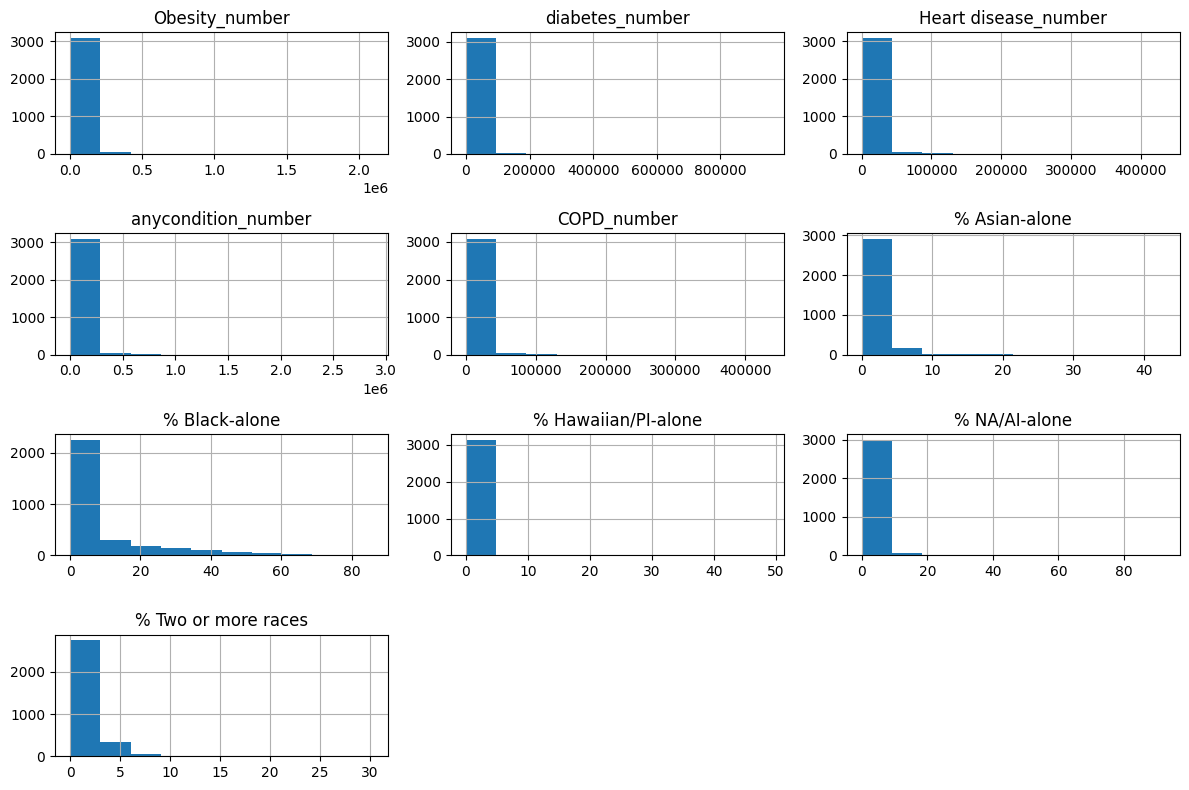

In [42]:
correlaciones = total_data.corrwith(total_data[['anycondition_number',
 'Obesity_number',
 'Heart disease_number',
 'COPD_number',
 'diabetes_number']]).abs().sort_values(ascending=False)
top_cols = correlaciones.head(10).index

# Graficar histogramas de esas columnas
total_data[top_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Plot de histogramas de variables categóricas

In [43]:
cat_cols = total_data.select_dtypes(include='object').columns

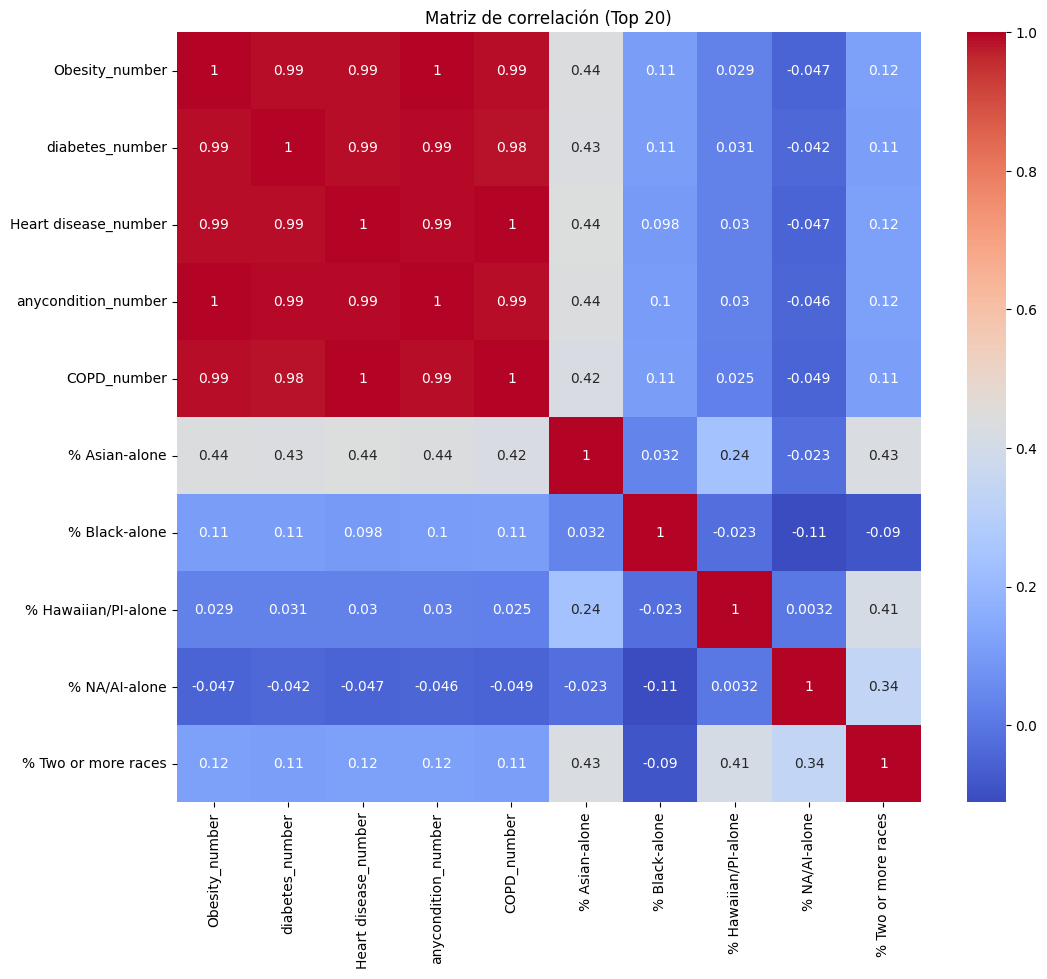

In [44]:
subset_cols = correlaciones.head(10).index
plt.figure(figsize=(12, 10))
sns.heatmap(total_data[subset_cols].corr(), cmap='coolwarm', annot=True)
plt.title("Matriz de correlación (Top 20)")
plt.show()

Guardar los datos 

In [45]:
total_data.to_csv('eda_total_data.csv',index=False)

Conclusiones 

- Limpieza de datos: Se eliminaron columnas con muchos valores nulos, baja varianza y aquellas consideradas irrelevantes para el análisis, dejando el dataset más enfocado y útil para el modelado.

- Distribución de variables: Los histogramas muestran la dispersión y posibles outliers en las variables numéricas más relevantes.

- Correlación: El heatmap de correlación revela qué variables están más relacionadas entre sí y con las condiciones de salud principales (obesidad, enfermedades cardíacas, EPOC, diabetes). Esto permite identificar variables que pueden ser útiles para la regresión.


## 3.1 Análisis multivariable

Factorización

In [46]:
if 'State' in total_data.columns:
    total_data['State'] = pd.factorize(total_data['State'])[0]

 Correlación con el target

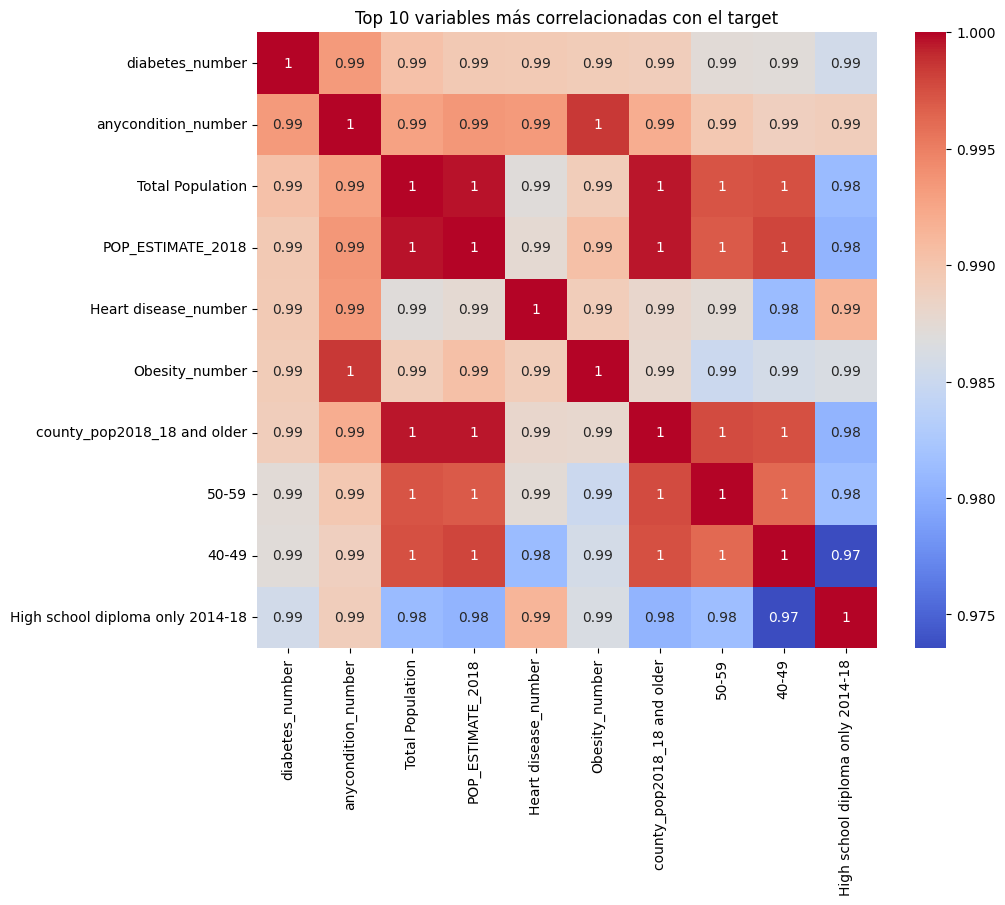

In [47]:
# Filtrar solo columnas numéricas (incluye el target)
num_cols = total_data.select_dtypes(include=[np.number]).columns

# Asegurarse que el target está dentro de estas columnas numéricas
if target not in num_cols:
    raise ValueError(f"El target {target} no es numérico o no está en las columnas numéricas")

# Calcular correlación solo con columnas numéricas
correlaciones = total_data[num_cols].corrwith(total_data[target]).abs().sort_values(ascending=False)

top_cols = correlaciones.head(10).index

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(total_data[top_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Top 10 variables más correlacionadas con el target")
plt.show()

 División Train/Test y escalado

In [48]:
# 1. Detectar columnas no numéricas
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
non_numeric_cols

# 2. One-hot encoding de columnas categóricas en train y test
X_train_encoded = pd.get_dummies(X_train, columns=non_numeric_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=non_numeric_cols, drop_first=True)

# Alinear columnas entre train y test
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train_encoded.shape, X_test_encoded.shape

# 3. Escalar los datos ya codificados
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

X_train_scaled.head()

,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,...,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number
1292,0.162374,-0.229775,-0.429454,-0.223780,-0.665485,-0.228216,-0.698327,-0.227030,0.585470,-0.231375,...,0.818916,0.874465,-0.224232,0.951061,0.856648,0.989521,-0.222477,0.209312,0.314479,-0.215940
2302,-0.836073,-0.188375,-0.736296,-0.176225,-0.785934,-0.163303,-0.073361,-0.139120,1.253363,-0.112664,...,0.255939,0.350729,-0.121664,0.350976,0.230367,0.413368,-0.117073,-0.060621,0.064137,-0.135257
761,0.464170,-0.168470,1.320194,-0.194740,-0.128551,-0.193726,0.159743,-0.199360,-0.000813,-0.218215,...,-0.744908,-0.696745,-0.215308,0.050934,0.037666,-0.009144,-0.194220,-0.330555,-0.329256,-0.188714
2194,0.576280,-0.067671,0.094875,-0.062335,0.335452,-0.044847,0.652423,-0.033104,0.247740,-0.044844,...,-0.432144,-0.487250,-0.021238,-0.420561,-0.347738,-0.431656,-0.021363,-0.639050,-0.722650,-0.057561
1241,0.234535,0.038603,0.173362,0.025430,0.070962,0.048850,0.159841,0.079829,-0.099992,0.119807,...,-0.056826,-0.173008,0.169262,0.222387,0.278543,0.221317,0.232009,-0.137745,-0.221967,0.100319


Selección de características

In [49]:
# 1. Crear imputador para reemplazar NaN por la media
imputer = SimpleImputer(strategy='mean')

# 2. Ajustar e imputar en X_train_scaled
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_scaled), columns=X_train_scaled.columns, index=X_train_scaled.index)

# 3. Imputar también en X_test_scaled (usar mismo imputador)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test_scaled.columns, index=X_test_scaled.index)

# 4. Selección de las 10 mejores variables
selector = SelectKBest(f_regression, k=10)
selector.fit(X_train_imputed, y_train)

selected_cols = X_train_imputed.columns[selector.get_support()]

X_train_selected = X_train_imputed[selected_cols]
X_test_selected = X_test_imputed[selected_cols]

selected_cols

Index(['PCTPOV017_2018', 'PCTPOV517_2018', 'anycondition_prevalence',
       'anycondition_Lower 95% CI', 'anycondition_Upper 95% CI',
       'Heart disease_prevalence', 'Heart disease_Lower 95% CI',
       'COPD_Lower 95% CI', 'diabetes_Lower 95% CI', 'diabetes_Upper 95% CI'],
      dtype='object')

 Guardado del dataset limpio

In [50]:
X_train_selected[target] = y_train.values
X_test_selected[target] = y_test.values

X_train_selected.to_csv("clean_dataset_train.csv", index=False)
X_test_selected.to_csv("clean_dataset_test.csv", index=False)

/tmp/ipykernel_785/3390703362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_selected[target] = y_train.values
/tmp/ipykernel_785/3390703362.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_selected[target] = y_test.values


Conclusión del análisis de datos

El análisis realizado nos ha permitido conocer mejor la información disponible. Hemos identificado cuáles son los factores más importantes que pueden influir en la cantidad de personas con diabetes en la población. Gracias a la revisión de los datos, sabemos qué variables tienen mayor relación entre sí y cuáles pueden ayudar a explicar el problema que estamos estudiando. Además, hemos eliminado información que no aporta valor y nos hemos asegurado de que los datos sean confiables y estén listos para construir un modelo que nos ayude a predecir y entender mejor la situación de la diabetes en la población analizada.

Hemos convertido un conjunto de datos muy grande y complejo en algo más manejable, claro y listo para responder preguntas importantes como:
¿Qué factores están más relacionados con la prevalencia de ciertas enfermedades? ¿Qué regiones podrían necesitar más atención médica? ¿Cómo influye la edad, el entorno rural o urbano, o la composición racial en los indicadores de salud?

# Modelo de Regresion lineal

In [54]:
# División del conjunto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Predicción
y_pred = modelo_lineal.predict(X_test)

# Evaluación
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

# ...existing code...
import pandas as pd
resultados = pd.DataFrame({
    "Métrica": ["R2", "MAE", "MSE", "RMSE"],
    "Valor": [r2, mae, mse, rmse]
})
display(resultados)
# ...existing code...



,Métrica,Valor
0,R2,0.999760
1,MAE,0.035123
2,MSE,0.001930
3,RMSE,0.043935


El modelo de regresión lineal desarrollado para predecir la prevalencia de diabetes en distintos condados ha demostrado ser altamente preciso. 

Con un nivel de ajuste del 99.97% (R²), el modelo logra explicar casi por completo las diferencias entre regiones a partir de variables como la distribución por edad, factores socioeconómicos y otras condiciones de salud. 

Los errores de predicción son mínimos, con una diferencia promedio de apenas 0.035 puntos porcentuales entre lo que el modelo predice y los valores reales. Esto indica que existe una fuerte relación entre las variables analizadas y la presencia de diabetes en la población, por lo que el modelo puede considerarse una herramienta confiable para estimar y analizar este indicador de salud a nivel territorial.